    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm.notebook import tqdm
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [94]:
inds_10 = pd.read_csv('csv/10_industry.csv')
inds_10['Date'] = pd.to_datetime(inds_10['Date'])
inds_10 = inds_10.set_index('Date')
inds_10.info()
inds_10

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6539 entries, 2000-01-03 to 2025-12-31
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NoDur   6539 non-null   float64
 1   Durbl   6539 non-null   float64
 2   Manuf   6539 non-null   float64
 3   Enrgy   6539 non-null   float64
 4   HiTec   6539 non-null   float64
 5   Telcm   6539 non-null   float64
 6   Shops   6539 non-null   float64
 7   Hlth    6539 non-null   float64
 8   Utils   6539 non-null   float64
 9   Other   6539 non-null   float64
dtypes: float64(10)
memory usage: 561.9 KB


,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
Date,,,,,,,,,,
2000-01-03,-1.65,-1.36,-2.49,-3.08,2.47,-1.26,-2.30,-0.58,-2.37,-3.31
2000-01-04,-1.81,-2.60,-2.68,-1.96,-5.34,-4.40,-3.28,-4.39,0.47,-3.68
2000-01-05,-0.13,-0.04,0.57,2.26,-1.09,0.01,-0.38,2.32,3.48,-0.38
2000-01-06,0.68,0.58,2.17,4.00,-4.93,-1.92,0.24,2.68,0.57,2.34
2000-01-07,2.11,4.81,3.21,1.16,3.51,0.93,4.27,7.61,1.13,1.99
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0.36,0.00,0.46,-0.33,0.17,0.64,0.51,0.58,0.38,0.42
2025-12-26,-0.07,-1.65,-0.13,-0.30,0.09,-0.18,0.13,-0.05,-0.16,-0.05
2025-12-29,0.19,-2.68,-0.38,1.02,-0.40,0.43,-0.21,-0.26,0.26,-0.57


In [95]:
# ── 고정 파라미터 ──
gamma = 0.0    # regularization 제거
x_min = 0.0
x_max = 1.0   # box constraint 제거

N_STOCKS = len(inds_10.columns)

HORIZON    = 126
REBAL      = 21
N          = HORIZON
M          = N_STOCKS   # 10
C          = 1.0
d          = 1.0
LAM_LIST   = [0.3, 0.5, 0.7]
DELTA_LIST = [20, 50]        # risk aversion
HIDDEN_DIM = 128
EPOCHS     = 500
BATCH_SIZE = 16
LR         = 1e-4
PATIENCE   = 100

# ── 실험 grid ──
LOOKBACK_LIST = [252, 504]
N1_LIST       = [0.1, 0.2, 0.3, 0.4, 0.5]

configs = [
    {"LOOKBACK": lb, "n1": n1}
    for lb in LOOKBACK_LIST
    for n1 in N1_LIST
]



In [96]:
inds_10 = inds_10.sort_index()
inds_10 = inds_10[~inds_10.index.duplicated(keep='first')]
inds_10 = inds_10 / 100.0

stock_names = inds_10.columns.tolist()

# =============================================================================
# 2. Train / Val / Test 분리 (날짜 기준)
# =============================================================================
TRAIN_START = "2000-01-01"
TRAIN_END   = "2012-12-31"   # Train : 13년
VAL_START   = "2013-01-01"
VAL_END     = "2017-12-31"   # Val   :  5년
BT_START    = "2018-01-01"
BT_END      = "2025-12-31"   # Test  :  8년

train_df = inds_10[TRAIN_START : TRAIN_END]
is_df    = inds_10[TRAIN_START : VAL_END]
val_df   = inds_10[VAL_START   : VAL_END]
bt_df    = inds_10[BT_START    : BT_END]

train_np = train_df.values
val_np   = val_df.values
bt_np    = bt_df.values

N_TRAIN = len(train_df)
N_VAL   = len(val_df)
N_BT    = len(bt_df)
N_DAYS  = len(inds_10)

print(f"전체  : {inds_10.index[0].date()} → {inds_10.index[-1].date()}  ({N_DAYS} days)")
print(f"Train : {train_df.index[0].date()} → {train_df.index[-1].date()}  ({N_TRAIN} days)")
print(f"Val   : {val_df.index[0].date()} → {val_df.index[-1].date()}  ({N_VAL} days)")
print(f"BT    : {bt_df.index[0].date()} → {bt_df.index[-1].date()}  ({N_BT} days)")
print(f"종목  : {stock_names}")

# =============================================================================
# 3. 슬라이딩 윈도우 생성
# =============================================================================
# Train 기간 통계로 표준화 (변수명 is_mean/is_std 유지 — .py 파일 호환)
is_mean = train_np.mean(axis=0)   # shape (10,)
is_std  = train_np.std(axis=0)    # shape (10,)

def make_windows(r_np, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z_raw  = r_np[t - lookback : t]                      # (lookback, 10)
        z_norm = (z_raw - is_mean) / (is_std + 1e-8)         # Train 기준 표준화
        r_real = r_np[t : t + horizon]
        samples.append((z_norm.flatten(), r_real))
    return samples

full_np       = np.vstack([train_np, val_np, bt_np])
VAL_START_IDX = N_TRAIN
BT_START_IDX  = N_TRAIN + N_VAL

for cfg in configs:
    LOOKBACK  = cfg["LOOKBACK"]
    n1        = cfg["n1"]
    INPUT_DIM = LOOKBACK * N_STOCKS

    train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=LOOKBACK, end=N_TRAIN)
    val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
    rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    print(f"\n[LOOKBACK={LOOKBACK}, n1={n1}]")
    print(f"  Train 학습 샘플 수  : {len(train_samples)}")
    print(f"  Val 전체 샘플 수    : {len(val_samples)}")
    print(f"  BT 리밸런싱 횟수    : {len(rebal_samples)}")

전체  : 2000-01-03 → 2025-12-31  (6539 days)
Train : 2000-01-03 → 2012-12-31  (3269 days)
Val   : 2013-01-02 → 2017-12-29  (1259 days)
BT    : 2018-01-02 → 2025-12-31  (2011 days)
종목  : ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other']

[LOOKBACK=252, n1=0.1]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=252, n1=0.2]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=252, n1=0.3]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=252, n1=0.4]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=252, n1=0.5]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=504, n1=0.1]
  Train 학습 샘플 수  : 2745
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=504, n1=0.2]
  Train 학습 샘플 수  : 2745
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=504, n1=0.3]
  Train 학습 샘플 수  : 2745
  Val 전체 샘플 수    : 1239
  B

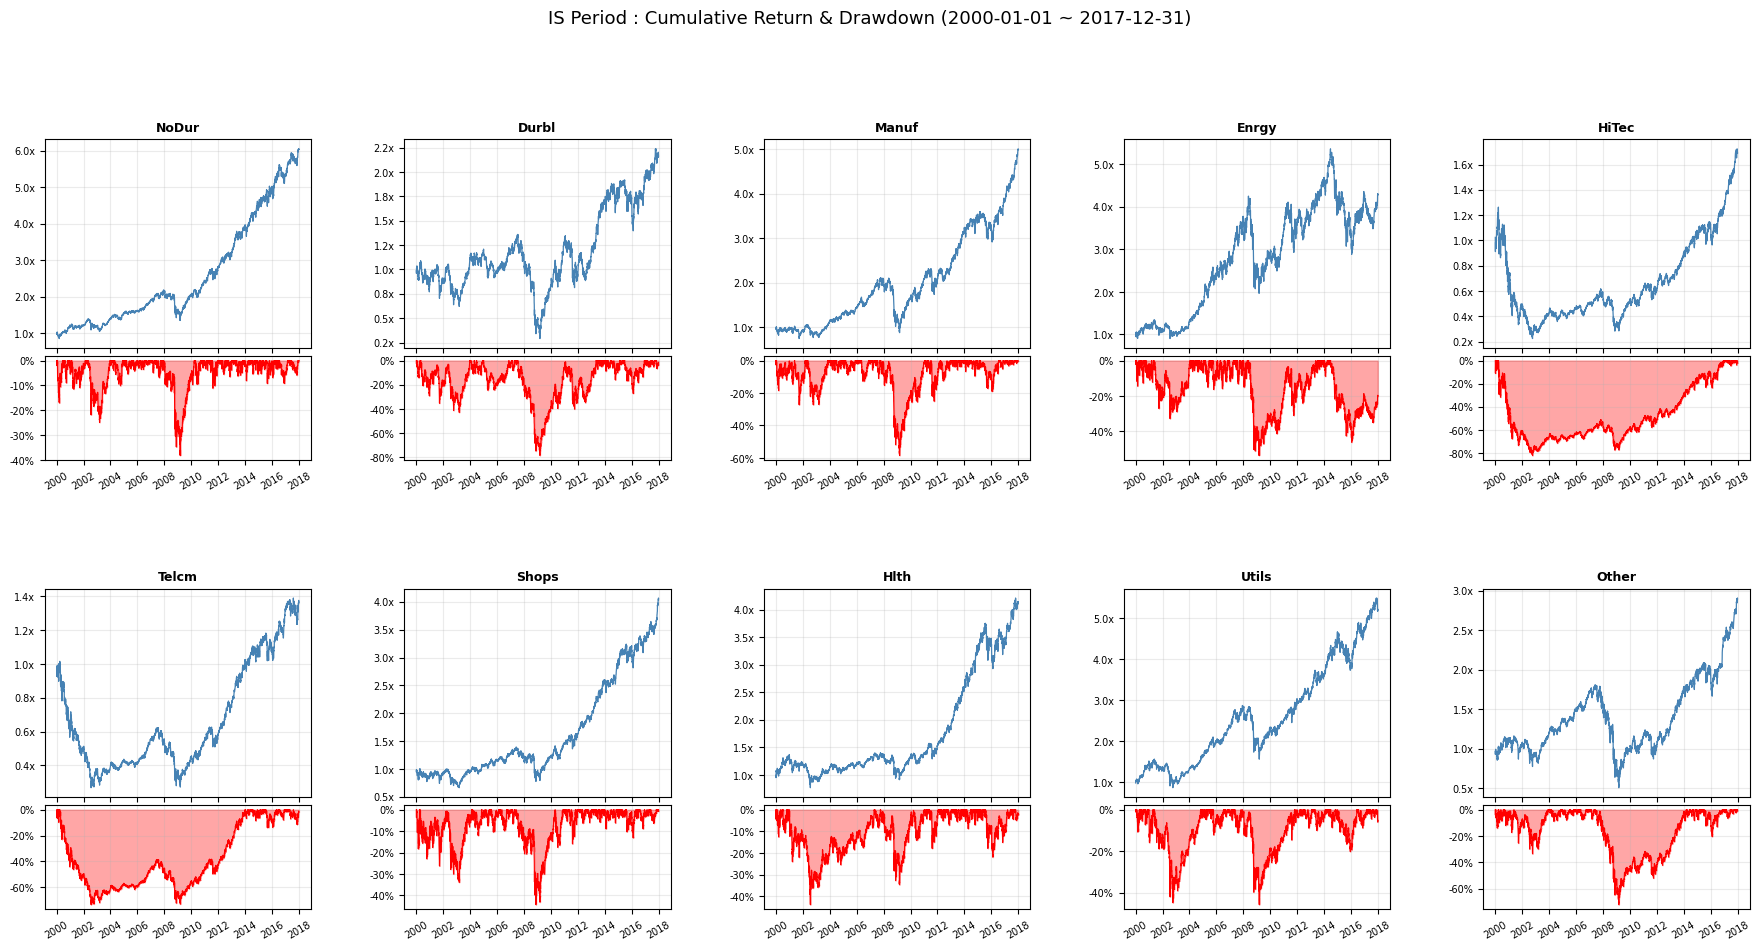

In [97]:
is_cum = (1 + is_df).cumprod()
is_dd  = (is_cum - is_cum.cummax()) / is_cum.cummax()

cols   = is_cum.columns.tolist()  # 10개 종목
N_COLS = 5
N_ROWS = 2  # 종목 행

fig = plt.figure(figsize=(22, 10))
outer = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig, hspace=0.4, wspace=0.35)

for i, col in enumerate(cols):
    row, c = divmod(i, N_COLS)
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[row, c],
        hspace=0.05, height_ratios=[2, 1]
    )

    ax_ret = fig.add_subplot(inner[0])
    ax_dd  = fig.add_subplot(inner[1], sharex=ax_ret)

    # 상단: 누적 수익률
    ax_ret.plot(is_cum.index, is_cum[col], color="steelblue", linewidth=0.9)
    ax_ret.set_title(col, fontsize=9, fontweight="bold")
    ax_ret.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.1f}x"))
    ax_ret.tick_params(axis="x", labelbottom=False)
    ax_ret.tick_params(labelsize=7)
    ax_ret.grid(True, alpha=0.25)

    # 하단: Drawdown
    ax_dd.fill_between(is_dd.index, is_dd[col], 0, alpha=0.35, color="red")
    ax_dd.plot(is_dd.index, is_dd[col], color="red", linewidth=0.8)
    ax_dd.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
    ax_dd.tick_params(labelsize=7)
    ax_dd.tick_params(axis="x", rotation=30)
    ax_dd.grid(True, alpha=0.25)

fig.suptitle(f"IS Period : Cumulative Return & Drawdown ({TRAIN_START} ~ {VAL_END})",
             fontsize=13, y=1.01)
plt.show()


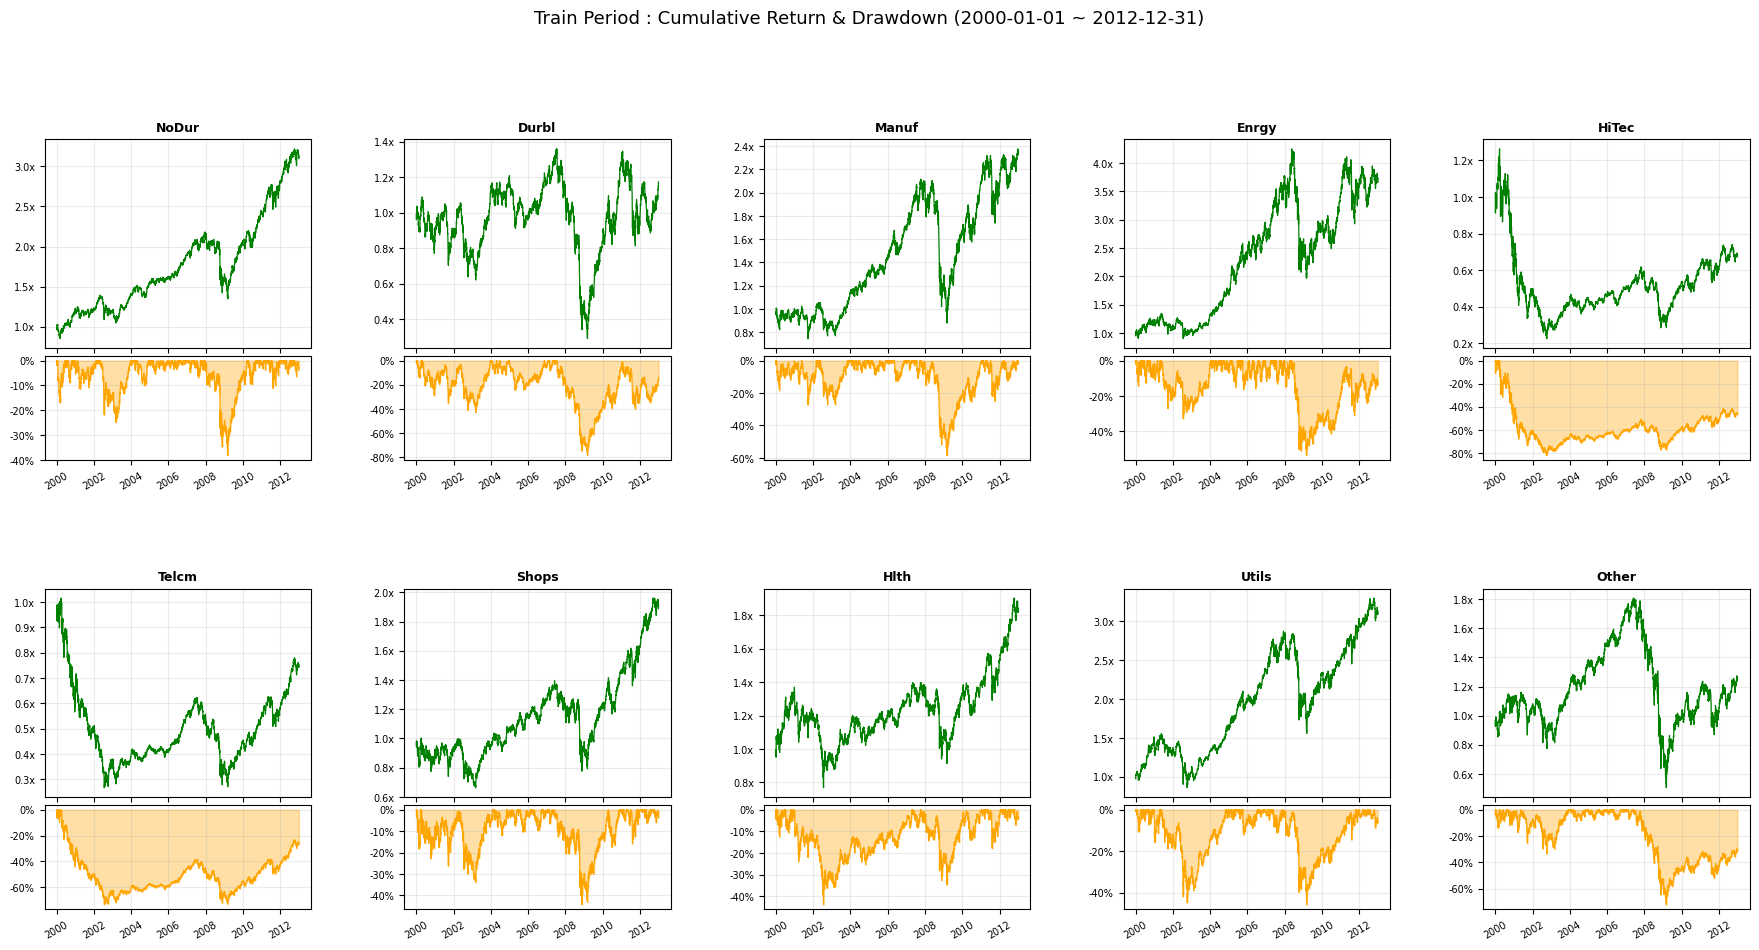

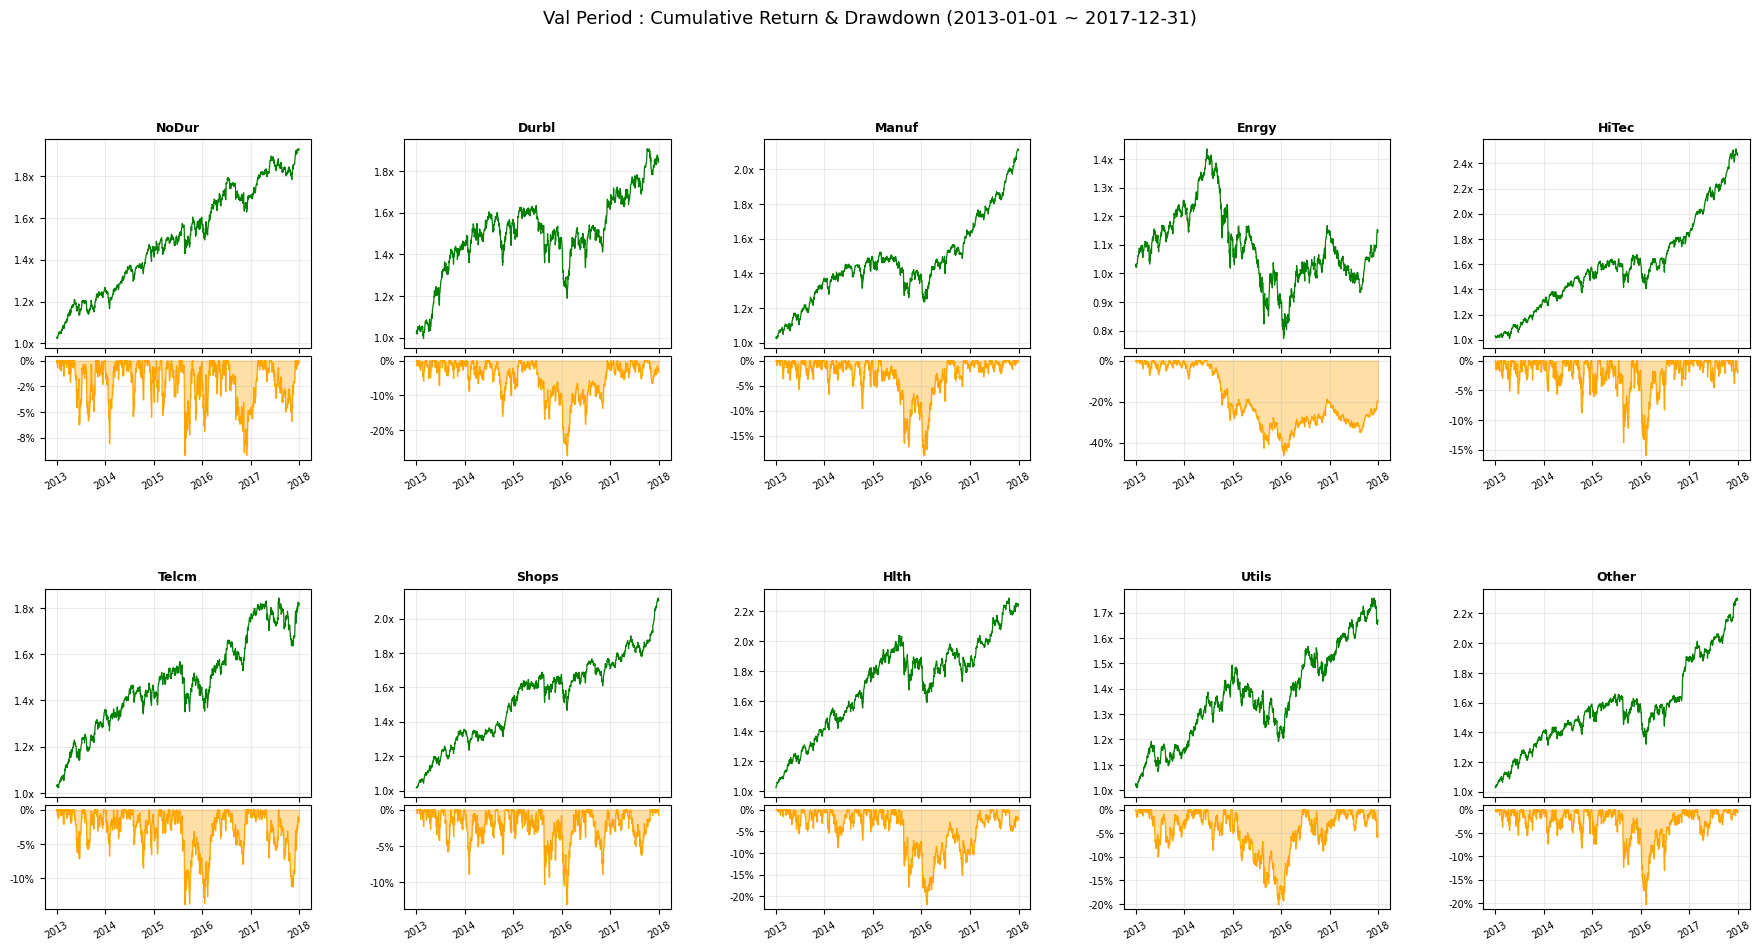

In [98]:
for period_df, period_name, p_start, p_end in [
    (train_df, "Train", TRAIN_START, TRAIN_END),
    (val_df,   "Val",   VAL_START,   VAL_END),
]:
    cum = (1 + period_df).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    cols = cum.columns.tolist()

    fig = plt.figure(figsize=(22, 10))
    outer = gridspec.GridSpec(2, 5, figure=fig, hspace=0.4, wspace=0.35)

    for i, col in enumerate(cols):
        row, c = divmod(i, 5)
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[row, c],
            hspace=0.05, height_ratios=[2, 1]
        )

        ax_ret = fig.add_subplot(inner[0])
        ax_dd  = fig.add_subplot(inner[1], sharex=ax_ret)

        # 상단: 누적 수익률
        ax_ret.plot(cum.index, cum[col], color="green", linewidth=0.9)
        ax_ret.set_title(col, fontsize=9, fontweight="bold")
        ax_ret.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.1f}x"))
        ax_ret.tick_params(axis="x", labelbottom=False)
        ax_ret.tick_params(labelsize=7)
        ax_ret.grid(True, alpha=0.25)

        # 하단: Drawdown
        ax_dd.fill_between(dd.index, dd[col], 0, alpha=0.35, color="orange")
        ax_dd.plot(dd.index, dd[col], color="orange", linewidth=0.8)
        ax_dd.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
        ax_dd.tick_params(labelsize=7)
        ax_dd.tick_params(axis="x", rotation=30)
        ax_dd.grid(True, alpha=0.25)

    fig.suptitle(f"{period_name} Period : Cumulative Return & Drawdown ({p_start} ~ {p_end})",
                 fontsize=13, y=1.01)
    plt.show()


In [99]:
def plot_multi_pnl(results_list, figsize=(14, 8), title="Cumulative PnL Comparison"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize,
                                   gridspec_kw={"height_ratios": [3, 1]},
                                   sharex=True)
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

    pv_store = []   # summary 계산용

    for (bt_results, label), color in zip(results_list, colors):
        pv = [1.0]
        for res in bt_results:
            w    = res["w_real"]
            base = pv[-1]
            pv.extend((base * (1 + w)).tolist())

        pv          = np.array(pv)
        running_max = np.maximum.accumulate(pv)
        drawdown    = (running_max - pv) / (running_max + 1e-10)
        total_ret   = pv[-1] - 1.0
        max_dd      = drawdown.max()
        calmar      = total_ret / (max_dd + 1e-10)

        full_label = f"{label}  R:{total_ret:.1%}  MDD:{max_dd:.1%}  Cal:{calmar:.2f}"
        ax1.plot(np.arange(len(pv)), pv, color=color, linewidth=1.5, label=full_label)
        ax2.plot(np.arange(len(pv)), -drawdown * 100, color=color, linewidth=1.0, alpha=0.7)
        pv_store.append((label, pv))

    ax1.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax1.set_ylabel("Portfolio Value")
    ax1.set_title(title)
    ax1.legend(loc="upper left", fontsize=8)
    ax1.grid(True, alpha=0.25)

    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Trading Days (BT Period)")
    ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax2.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

    # ── Summary Table ──
    print(f"\n{'─'*75}")
    print(f"  {'Label':<35}  {'Ann.Ret':>8}  {'Ann.Vol':>8}  {'MDD':>8}  {'Calmar':>7}")
    print(f"{'─'*75}")
    for label, pv in pv_store:
        daily_rets  = np.diff(pv) / (pv[:-1] + 1e-10)
        n_days      = len(daily_rets)
        ann_ret     = (pv[-1] ** (252 / n_days)) - 1      # 기하 연율화
        ann_vol     = daily_rets.std() * np.sqrt(252)
        running_max = np.maximum.accumulate(pv)
        max_dd      = ((running_max - pv) / (running_max + 1e-10)).max()
        calmar      = ann_ret / (max_dd + 1e-10)
        print(f"  {label:<35}  {ann_ret:>8.2%}  {ann_vol:>8.2%}  {max_dd:>8.2%}  {calmar:>7.2f}")
    print(f"{'─'*75}")


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_mdd_distribution(all_results, title_prefix="DFL-MDD"):
    """
    all_results: list of (results, label) tuples
                 results는 backtest_dfl_mdd의 반환값 (list of dicts with 'M_real')
    """
    n_configs = len(all_results)
    fig = plt.figure(figsize=(16, 5 * n_configs))
    gs = gridspec.GridSpec(n_configs, 3, figure=fig, hspace=0.5, wspace=0.35)

    for row, (results, label) in enumerate(all_results):
        mdds = np.array([r["M_real"] for r in results]) * 100  # % 단위

        windows = np.arange(1, len(mdds) + 1)
        mean_mdd = mdds.mean()
        median_mdd = np.median(mdds)
        p95_mdd = np.percentile(mdds, 95)

        # ── 1. 시계열 바 차트 ──────────────────────────────
        ax1 = fig.add_subplot(gs[row, 0])
        colors = ["#d62728" if v > p95_mdd else "#1f77b4" for v in mdds]
        ax1.bar(windows, mdds, color=colors, alpha=0.8, width=0.7)
        ax1.axhline(mean_mdd,   color="red",    linestyle="--", lw=1.5, label=f"Mean={mean_mdd:.2f}%")
        ax1.axhline(median_mdd, color="orange", linestyle=":",  lw=1.5, label=f"Median={median_mdd:.2f}%")
        ax1.set_xlabel("Rebalancing Window")
        ax1.set_ylabel("MDD (%)")
        ax1.set_title(f"{label}\nPer-Window MDD (time series)")
        ax1.legend(fontsize=8)

        # ── 2. 히스토그램 + KDE ────────────────────────────
        ax2 = fig.add_subplot(gs[row, 1])
        n_bins = min(20, max(5, len(mdds) // 3))
        ax2.hist(mdds, bins=n_bins, color="#1f77b4", alpha=0.7, edgecolor="white",
                 density=True, label="Histogram")

        # KDE
        from scipy.stats import gaussian_kde
        if len(mdds) >= 4:
            kde = gaussian_kde(mdds, bw_method="scott")
            xs  = np.linspace(mdds.min() * 0.8, mdds.max() * 1.1, 300)
            ax2.plot(xs, kde(xs), color="navy", lw=2, label="KDE")

        ax2.axvline(mean_mdd,   color="red",    linestyle="--", lw=1.5, label=f"Mean={mean_mdd:.2f}%")
        ax2.axvline(median_mdd, color="orange", linestyle=":",  lw=1.5, label=f"Median={median_mdd:.2f}%")
        ax2.axvline(p95_mdd,    color="purple", linestyle="-.", lw=1.5, label=f"P95={p95_mdd:.2f}%")
        ax2.set_xlabel("MDD (%)")
        ax2.set_ylabel("Density")
        ax2.set_title(f"{label}\nMDD Distribution")
        ax2.legend(fontsize=8)

        # ── 3. Box + Strip plot ────────────────────────────
        ax3 = fig.add_subplot(gs[row, 2])
        bp = ax3.boxplot(mdds, vert=True, patch_artist=True,
                         boxprops=dict(facecolor="#aec7e8", alpha=0.7),
                         medianprops=dict(color="orange", lw=2),
                         whiskerprops=dict(lw=1.5),
                         flierprops=dict(marker="o", markersize=4,
                                         markerfacecolor="#d62728", alpha=0.7))
        # jitter strip
        jitter = np.random.uniform(-0.1, 0.1, size=len(mdds))
        ax3.scatter(1 + jitter, mdds, alpha=0.5, s=20, color="#1f77b4", zorder=3)

        # 요약 통계 텍스트
        stats_text = (
            f"n={len(mdds)}\n"
            f"Mean  : {mean_mdd:.2f}%\n"
            f"Median: {median_mdd:.2f}%\n"
            f"Std   : {mdds.std():.2f}%\n"
            f"Min   : {mdds.min():.2f}%\n"
            f"Max   : {mdds.max():.2f}%\n"
            f"P95   : {p95_mdd:.2f}%"
        )
        ax3.text(1.35, mdds.max(), stats_text, fontsize=8,
                 va="top", ha="left",
                 bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
                           edgecolor="gray", alpha=0.9))
        ax3.set_xticks([])
        ax3.set_ylabel("MDD (%)")
        ax3.set_title(f"{label}\nBoxplot")

    fig.suptitle(f"{title_prefix} — Per-Window MDD Distribution",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


############################################################
  DFL-MDD  |  delta = 20
############################################################

  Config: LOOKBACK=252, n1=0.1

── DFL-MDD Training (with Val Early Stopping) ──
  Epoch   1/500  train=0.018373  val=-0.001275  *
  Epoch   5/500  train=0.014402  val=-0.001406  *


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/diffcp/cone_program.py:522: UserWarning: Solved/Inaccurate.
  warnings.warn("Solved/Inaccurate.")


  Epoch  10/500  train=0.013790  val=0.001798  (5/50)
  Epoch  15/500  train=0.014091  val=0.002385  (10/50)
  Epoch  20/500  train=0.012159  val=0.003895  (15/50)
  Epoch  25/500  train=0.018306  val=0.005024  (20/50)
  Epoch  30/500  train=0.016522  val=0.003492  (25/50)
  Epoch  35/500  train=0.012582  val=0.002256  (30/50)
  Epoch  40/500  train=0.009752  val=0.003352  (35/50)
  Epoch  45/500  train=0.010822  val=0.004686  (40/50)
  Epoch  50/500  train=0.010851  val=0.000866  (45/50)
  Epoch  55/500  train=0.007819  val=0.002188  (50/50)
  Early stopping at epoch 55  (best val=-0.001406)

── Backtest : DFL-MDD ──
 Win    R_real    Sharpe    MDD(%)  Top-3 weights
---------------------------------------------------------------------------


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 679.50it/s]

    1    0.0040    0.0221   1.4492%  {'NoDur': 0.671, 'Utils': 0.329, 'Shops': 0.0}
    2   -0.0544   -0.3010   7.9622%  {'NoDur': 0.683, 'Utils': 0.317, 'HiTec': 0.0}
    3   -0.0012   -0.0063   8.6057%  {'NoDur': 0.599, 'Utils': 0.401, 'Shops': 0.0}
    4   -0.0298   -0.1507   9.2365%  {'NoDur': 0.686, 'Utils': 0.314, 'Shops': -0.0}
    5    0.0173    0.0942   9.4137%  {'NoDur': 0.548, 'Utils': 0.283, 'Hlth': 0.169}
    6    0.0384    0.1560   9.4137%  {'NoDur': 0.956, 'Utils': 0.044, 'Hlth': -0.0}
    7    0.0279    0.1426   9.4137%  {'NoDur': 0.463, 'Enrgy': 0.309, 'Hlth': 0.228}
    8    0.0067    0.0336   9.4137%  {'NoDur': 0.622, 'Utils': 0.378, 'Enrgy': 0.0}
    9    0.0055    0.0226   9.4137%  {'NoDur': 0.925, 'HiTec': 0.075, 'Shops': 0.0}
   10    0.0102    0.0510   9.4137%  {'Utils': 0.512, 'NoDur': 0.488, 'Hlth': 0.0}
   11   -0.0005   -0.0023   9.4137%  {'NoDur': 0.808, 'Hlth': 0.192, 'Shops': 0.0}
   12   -0.0813   -0.4292  13.2959%  {'NoDur': 0.405, 'Utils': 0.396, 'Hlth

...

Backtesting: 100%|██████████| 95/95 [00:00<00:00, 688.80it/s]

    1    0.0696    0.2784   1.5071%  {'HiTec': 0.867, 'Telcm': 0.133, 'NoDur': -0.0}
    2   -0.0197   -0.0906   9.7161%  {'HiTec': 0.723, 'Telcm': 0.277, 'NoDur': -0.0}
    3   -0.0387   -0.1422   9.7161%  {'HiTec': 1.0, 'Telcm': 0.0, 'Hlth': 0.0}
    4   -0.0084   -0.0409   9.7161%  {'Telcm': 0.64, 'HiTec': 0.258, 'Utils': 0.102}
    5    0.0653    0.2793   9.7161%  {'HiTec': 0.672, 'Manuf': 0.328, 'Utils': -0.0}
    6    0.0087    0.0373   9.7161%  {'HiTec': 0.733, 'Telcm': 0.267, 'Manuf': -0.0}
    7    0.0223    0.1018   9.7161%  {'HiTec': 0.643, 'Telcm': 0.357, 'Enrgy': 0.0}
    8    0.0555    0.2250   9.7161%  {'HiTec': 0.834, 'Telcm': 0.166, 'NoDur': -0.0}
    9    0.0053    0.0220   9.7161%  {'HiTec': 0.791, 'Telcm': 0.209, 'Manuf': -0.0}
   10   -0.1123   -0.4005  13.1876%  {'HiTec': 1.0, 'Telcm': 0.0, 'Manuf': 0.0}
   11    0.0068    0.0259  15.2997%  {'HiTec': 0.862, 'Telcm': 0.138, 'NoDur': -0.0}
   12   -0.1012   -0.4737  23.6144%  {'NoDur': 0.734, 'HiTec': 0.266, 'Telcm'


── DFL-MDD Training (with Val Early Stopping) ──
  Epoch   1/500  train=0.020719  val=0.006878  *
  Epoch   5/500  train=0.016716  val=0.005895  (2/50)
  Epoch  10/500  train=0.015081  val=0.005056  (7/50)
  Epoch  15/500  train=0.014963  val=0.004814  (12/50)
  Epoch  20/500  train=0.014835  val=0.004814  (17/50)
  Epoch  25/500  train=0.014508  val=0.004694  (22/50)
  Epoch  30/500  train=0.014030  val=0.004671  (27/50)
  Epoch  35/500  train=0.013577  val=0.004928  (32/50)
  Epoch  40/500  train=0.012885  val=0.004733  (37/50)
  Epoch  45/500  train=0.013182  val=0.004786  (42/50)
  Epoch  50/500  train=0.013522  val=0.004728  (47/50)
  Early stopping at epoch 53  (best val=0.003158)

── Backtest : DFL-MDD ──
 Win    R_real    Sharpe    MDD(%)  Top-3 weights
---------------------------------------------------------------------------


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 694.39it/s]

    1    0.0408    0.1560   1.5703%  {'Manuf': 1.0, 'NoDur': 0.0, 'Enrgy': 0.0}
    2   -0.0580   -0.2350   8.5128%  {'NoDur': 1.0, 'Enrgy': 0.0, 'Durbl': 0.0}
    3   -0.0171   -0.0660  10.3132%  {'Manuf': 1.0, 'NoDur': 0.0, 'Telcm': -0.0}
    4   -0.0361   -0.1370  12.1294%  {'Manuf': 1.0, 'NoDur': 0.0, 'Enrgy': 0.0}
    5    0.0222    0.0873  12.2437%  {'NoDur': 1.0, 'Manuf': 0.0, 'Telcm': 0.0}
    6   -0.0202   -0.0759  12.9003%  {'Manuf': 1.0, 'NoDur': 0.0, 'Telcm': -0.0}
    7    0.0407    0.1557  12.9003%  {'Manuf': 1.0, 'NoDur': 0.0, 'Enrgy': -0.0}
    8    0.0089    0.0339  12.9003%  {'Manuf': 1.0, 'NoDur': 0.0, 'Telcm': 0.0}
    9    0.0058    0.0230  12.9003%  {'NoDur': 1.0, 'Manuf': 0.0, 'Enrgy': 0.0}
   10    0.0116    0.0464  12.9003%  {'NoDur': 1.0, 'Manuf': 0.0, 'Durbl': 0.0}
   11   -0.0124   -0.0491  12.9003%  {'NoDur': 1.0, 'Manuf': 0.0, 'HiTec': -0.0}
   12   -0.1122   -0.4475  20.4721%  {'NoDur': 1.0, 'Manuf': 0.0, 'Enrgy': 0.0}
   13    0.0725    0.2844  20.4721% 

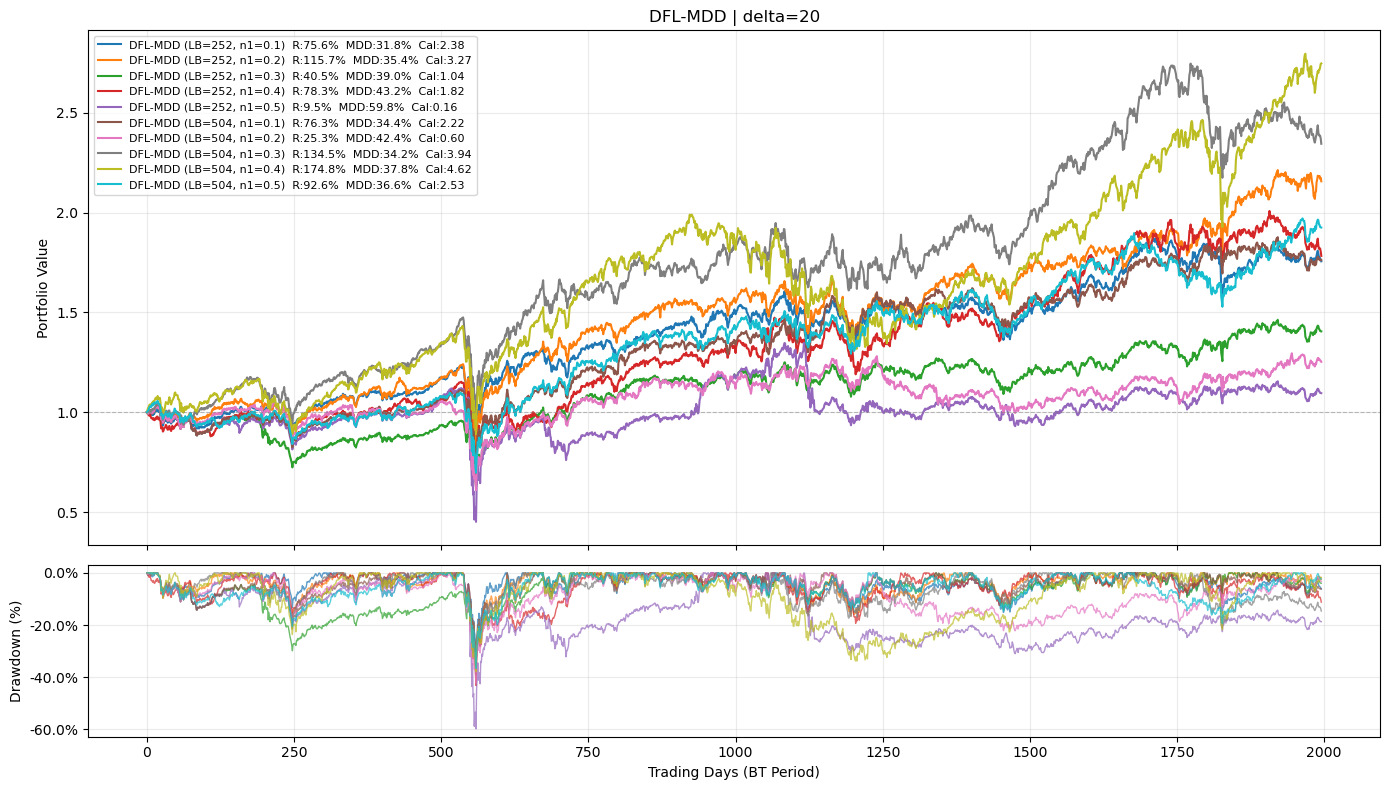


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  DFL-MDD (LB=252, n1=0.1)                7.37%    17.02%    31.76%     0.23
  DFL-MDD (LB=252, n1=0.2)               10.20%    18.39%    35.37%     0.29
  DFL-MDD (LB=252, n1=0.3)                4.39%    17.93%    39.04%     0.11
  DFL-MDD (LB=252, n1=0.4)                7.58%    21.44%    43.15%     0.18
  DFL-MDD (LB=252, n1=0.5)                1.16%    29.09%    59.79%     0.02
  DFL-MDD (LB=504, n1=0.1)                7.42%    17.90%    34.42%     0.22
  DFL-MDD (LB=504, n1=0.2)                2.89%    20.12%    42.38%     0.07
  DFL-MDD (LB=504, n1=0.3)               11.37%    20.16%    34.16%     0.33
  DFL-MDD (LB=504, n1=0.4)               13.62%    23.03%    37.83%     0.36
  DFL-MDD (LB=504, n1=0.5)                8.63%    18.72%    36.57%     0.24


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 632.25it/s]

    1    0.0106    0.0540   1.1771%  {'NoDur': 0.809, 'Utils': 0.191, 'HiTec': 0.0}
    2   -0.0580   -0.2508   8.0180%  {'NoDur': 1.0, 'Durbl': 0.0, 'HiTec': 0.0}
    3    0.0187    0.0892   8.0180%  {'Utils': 0.79, 'NoDur': 0.21, 'Hlth': 0.0}
    4   -0.0099   -0.0524   8.0180%  {'Utils': 0.536, 'NoDur': 0.464, 'Hlth': 0.0}
    5    0.0222    0.0873   8.0180%  {'NoDur': 1.0, 'Hlth': 0.0, 'HiTec': 0.0}
    6    0.0419    0.2103   8.0180%  {'Utils': 0.641, 'NoDur': 0.359, 'Durbl': 0.0}
    7    0.0226    0.0881   8.0180%  {'NoDur': 1.0, 'Hlth': 0.0, 'HiTec': 0.0}
    8    0.0202    0.0829   8.0180%  {'Utils': 0.919, 'NoDur': 0.081, 'Hlth': 0.0}
    9    0.0080    0.0338   8.0180%  {'NoDur': 0.866, 'Hlth': 0.134, 'Durbl': 0.0}
   10    0.0088    0.0336   8.0180%  {'Utils': 0.997, 'NoDur': 0.003, 'Hlth': 0.0}
   11    0.0118    0.0440   8.0180%  {'Utils': 1.0, 'NoDur': 0.0, 'Durbl': 0.0}
   12   -0.0774   -0.3709  11.5783%  {'Utils': 0.541, 'NoDur': 0.459, 'Durbl': 0.0}
   13    0.0725  


── DFL-MDD Training (with Val Early Stopping) ──
  Epoch   1/500  train=0.020217  val=0.002941  *
  Epoch   5/500  train=0.014494  val=0.003149  (1/50)
  Epoch  10/500  train=0.014537  val=0.003781  (6/50)
  Epoch  15/500  train=0.012868  val=0.004431  (11/50)
  Epoch  20/500  train=0.021891  val=0.012906  (16/50)
  Epoch  25/500  train=0.012867  val=0.002314  (3/50)
  Epoch  30/500  train=0.011655  val=0.003648  (8/50)
  Epoch  35/500  train=0.011453  val=0.004531  (13/50)
  Epoch  40/500  train=0.010851  val=0.004479  (18/50)
  Epoch  45/500  train=0.009644  val=0.004084  (23/50)
  Epoch  50/500  train=0.009482  val=0.004559  (28/50)
  Epoch  55/500  train=0.010202  val=0.006326  (33/50)
  Epoch  60/500  train=0.009514  val=0.005149  (38/50)
  Epoch  65/500  train=0.008951  val=0.003721  (43/50)
  Epoch  70/500  train=0.010290  val=0.002373  (48/50)
  Early stopping at epoch 72  (best val=0.000356)

── Backtest : DFL-MDD ──
 Win    R_real    Sharpe    MDD(%)  Top-3 weights
---------

Backtesting: 100%|██████████| 95/95 [00:00<00:00, 649.17it/s]

...

Backtesting: 100%|██████████| 95/95 [00:00<00:00, 627.10it/s]

    1    0.0197    0.0787   1.1154%  {'NoDur': 1.0, 'Durbl': 0.0, 'Enrgy': 0.0}
    2   -0.0580   -0.2350   8.0984%  {'NoDur': 1.0, 'Enrgy': 0.0, 'Durbl': 0.0}
    3   -0.0217   -0.0868  11.0436%  {'NoDur': 1.0, 'Enrgy': 0.0, 'Manuf': 0.0}
    4   -0.0579   -0.2298  14.1315%  {'NoDur': 1.0, 'Enrgy': 0.0, 'Durbl': 0.0}
    5    0.0222    0.0873  14.2432%  {'NoDur': 1.0, 'Enrgy': 0.0, 'Durbl': 0.0}
    6    0.0381    0.1503  14.2432%  {'NoDur': 1.0, 'Enrgy': 0.0, 'Manuf': 0.0}
    7    0.0226    0.0899  14.2432%  {'NoDur': 1.0, 'Enrgy': 0.0, 'Utils': -0.0}
    8   -0.0027   -0.0107  14.2432%  {'NoDur': 1.0, 'Enrgy': 0.0, 'Manuf': 0.0}
    9    0.0058    0.0230  14.2432%  {'NoDur': 1.0, 'Enrgy': 0.0, 'Utils': 0.0}
   10    0.0116    0.0464  14.2432%  {'NoDur': 1.0, 'Telcm': 0.0, 'Enrgy': 0.0}
   11   -0.0124   -0.0491  14.2432%  {'NoDur': 1.0, 'Enrgy': 0.0, 'Utils': 0.0}
   12   -0.1122   -0.4475  20.0222%  {'NoDur': 1.0, 'Enrgy': 0.0, 'Telcm': 0.0}
   13    0.0725    0.2844  20.0222%  {'


── DFL-MDD Training (with Val Early Stopping) ──
  Epoch   1/500  train=0.023594  val=0.005134  *
  Epoch   5/500  train=0.015208  val=0.004814  (3/50)
  Epoch  10/500  train=0.015116  val=0.004814  (8/50)
  Epoch  15/500  train=0.015048  val=0.004814  (13/50)
  Epoch  20/500  train=0.015121  val=0.004814  (18/50)
  Epoch  25/500  train=0.015112  val=0.004814  (23/50)
  Epoch  30/500  train=0.015160  val=0.004814  (28/50)
  Epoch  35/500  train=0.015214  val=0.004814  (33/50)
  Epoch  40/500  train=0.015123  val=0.004814  (38/50)
  Epoch  45/500  train=0.018410  val=0.006215  (43/50)
  Epoch  50/500  train=0.015456  val=0.005587  (2/50)
  Epoch  55/500  train=0.014384  val=0.005071  (7/50)
  Epoch  60/500  train=0.014754  val=0.005100  (12/50)
  Epoch  65/500  train=0.014355  val=0.004780  (17/50)
  Epoch  70/500  train=0.014052  val=0.004698  (22/50)
  Epoch  75/500  train=0.013272  val=0.004698  (27/50)
  Epoch  80/500  train=0.012440  val=0.004012  (32/50)
  Epoch  85/500  train=0.

Backtesting: 100%|██████████| 95/95 [00:00<00:00, 604.44it/s]

    1    0.0288    0.1301   1.2169%  {'Telcm': 0.763, 'NoDur': 0.237, 'Hlth': -0.0}
    2   -0.0642   -0.3136   8.3311%  {'Telcm': 0.677, 'NoDur': 0.323, 'Enrgy': 0.0}
    3   -0.0217   -0.0868  11.7331%  {'NoDur': 1.0, 'Durbl': 0.0, 'Telcm': 0.0}
    4   -0.0579   -0.2298  14.7970%  {'NoDur': 1.0, 'Telcm': 0.0, 'Manuf': 0.0}
    5    0.0222    0.0873  14.9078%  {'NoDur': 1.0, 'Telcm': 0.0, 'Manuf': -0.0}
    6    0.0540    0.2605  14.9078%  {'Telcm': 0.611, 'NoDur': 0.389, 'Enrgy': 0.0}
    7    0.0226    0.0899  14.9078%  {'NoDur': 1.0, 'Telcm': 0.0, 'Manuf': 0.0}
    8    0.0244    0.1106  14.9078%  {'Telcm': 0.736, 'NoDur': 0.264, 'Manuf': 0.0}
    9    0.0058    0.0230  14.9078%  {'NoDur': 1.0, 'Telcm': 0.0, 'Durbl': 0.0}
   10    0.0116    0.0464  14.9078%  {'NoDur': 1.0, 'Enrgy': 0.0, 'Hlth': 0.0}
   11   -0.0124   -0.0491  14.9078%  {'NoDur': 1.0, 'Telcm': 0.0, 'Manuf': 0.0}
   12   -0.1122   -0.4475  17.2381%  {'NoDur': 1.0, 'Telcm': 0.0, 'Enrgy': 0.0}
   13    0.0608    0.291

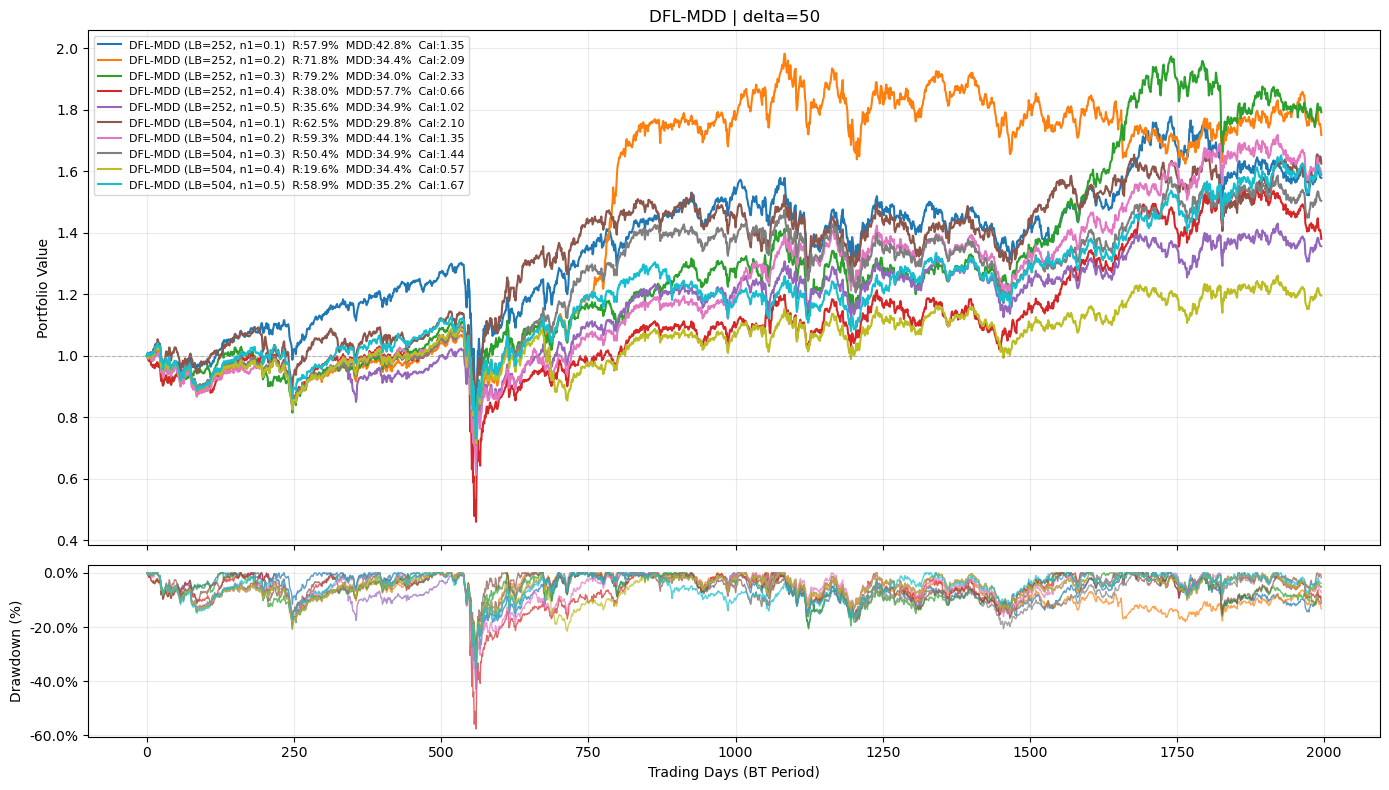


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  DFL-MDD (LB=252, n1=0.1)                5.94%    20.57%    42.80%     0.14
  DFL-MDD (LB=252, n1=0.2)                7.08%    18.42%    34.41%     0.21
  DFL-MDD (LB=252, n1=0.3)                7.65%    18.78%    33.96%     0.23
  DFL-MDD (LB=252, n1=0.4)                4.16%    26.59%    57.66%     0.07
  DFL-MDD (LB=252, n1=0.5)                3.92%    17.59%    34.89%     0.11
  DFL-MDD (LB=504, n1=0.1)                6.33%    18.11%    29.79%     0.21
  DFL-MDD (LB=504, n1=0.2)                6.06%    19.25%    44.12%     0.14
  DFL-MDD (LB=504, n1=0.3)                5.29%    17.44%    34.94%     0.15
  DFL-MDD (LB=504, n1=0.4)                2.29%    17.74%    34.41%     0.07
  DFL-MDD (LB=504, n1=0.5)                6.02%    17.54%    35.22%     0.17


In [100]:
import importlib

import dfl_mdd
importlib.reload(dfl_mdd)
from dfl_mdd import (
    PredictionModel, build_optimization_layer, solve_portfolio,
    compute_cumulative_path, compute_realized_path, compute_return,
    compute_max_drawdown, dfl_loss, forward_pass,
    train_dfl_mdd, backtest_dfl_mdd, plot_pnl,
)

for delta_val in DELTA_LIST:
    for lam_val in LAM_LIST:
        all_results_dfl_mdd = []

        for cfg in configs:
            LOOKBACK = cfg["LOOKBACK"]
            n1       = cfg["n1"]

            INPUT_DIM = LOOKBACK * N_STOCKS

            train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                         start=LOOKBACK, end=N_TRAIN)
            val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                         start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
            val_samples   = val_samples[::HORIZON]
            rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                         start=BT_START_IDX, end=BT_START_IDX + N_BT)
            rebal_samples = rebal_samples[::REBAL]

            torch.manual_seed(42)

            pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
            opt_layer  = build_optimization_layer(N, M, gamma, delta=delta_val)

            pred_model, train_inaccurate = train_dfl_mdd(
                pred_model, opt_layer, train_samples, val_samples,
                epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                n1=n1, C=C, d=d, x_min=x_min, x_max=x_max, lam=lam_val,
                is_mean=is_mean, is_std=is_std, delta=delta_val,
                patience=PATIENCE, lr_patience=20, lr_factor=0.5,
            )

            bt_dfl_mdd, bt_inaccurate = backtest_dfl_mdd(
                pred_model=pred_model, opt_layer=opt_layer,
                rebal_samples=rebal_samples, N=HORIZON, d=d, C=C,
                n1=n1, x_min=x_min, x_max=x_max,
                delta=delta_val, is_mean=is_mean, is_std=is_std,
                stock_names=stock_names, rebal=REBAL,
            )
            all_results_dfl_mdd.append((bt_dfl_mdd, f"DFL-MDD (LB={LOOKBACK}, n1={n1})"))

        plot_multi_pnl(all_results_dfl_mdd, title=f"DFL-MDD | delta={delta_val}, lam={lam_val}")
        
        plot_mdd_distribution(
            all_results_dfl_mdd,
            title_prefix=f"DFL-MDD | delta={delta_val}, lam={lam_val}"
        )


############################################################
  PTO-MDD  |  delta = 20
############################################################

  Config: LOOKBACK=252, n1=0.1

── PTO-MDD Training (MSE + Val Early Stopping) ──
  Epoch   1/500  train=0.003940  val=0.001137  *
  Epoch   5/500  train=0.000282  val=0.000170  *
  Epoch  10/500  train=0.000222  val=0.000100  *
  Epoch  15/500  train=0.000222  val=0.000088  *
  Epoch  20/500  train=0.000223  val=0.000086  *
  Epoch  25/500  train=0.000224  val=0.000085  *
  Epoch  30/500  train=0.000226  val=0.000085  (2/50)
  Epoch  35/500  train=0.000224  val=0.000085  (3/50)
  Epoch  40/500  train=0.000224  val=0.000085  (8/50)
  Epoch  45/500  train=0.000223  val=0.000085  (4/50)
  Epoch  50/500  train=0.000223  val=0.000085  (9/50)
  Epoch  55/500  train=0.000224  val=0.000085  (14/50)
  Epoch  60/500  train=0.000223  val=0.000085  (19/50)
  Epoch  65/500  train=0.000223  val=0.000085  (24/50)
  Epoch  70/500  train=0.000224  val=0.0

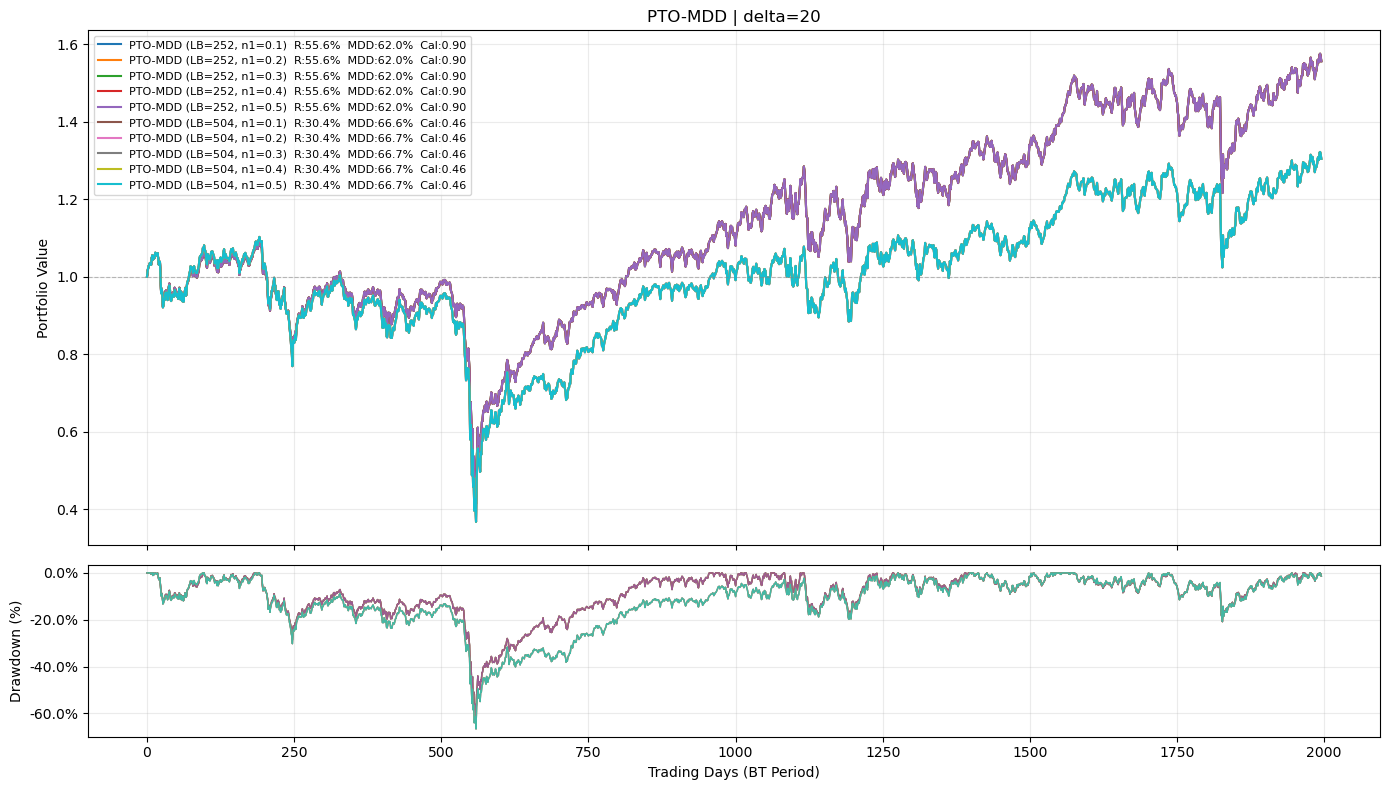


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  PTO-MDD (LB=252, n1=0.1)                5.74%    25.63%    62.05%     0.09
  PTO-MDD (LB=252, n1=0.2)                5.74%    25.63%    62.05%     0.09
  PTO-MDD (LB=252, n1=0.3)                5.74%    25.63%    62.05%     0.09
  PTO-MDD (LB=252, n1=0.4)                5.74%    25.63%    62.05%     0.09
  PTO-MDD (LB=252, n1=0.5)                5.74%    25.63%    62.05%     0.09
  PTO-MDD (LB=504, n1=0.1)                3.41%    27.51%    66.65%     0.05
  PTO-MDD (LB=504, n1=0.2)                3.41%    27.51%    66.65%     0.05
  PTO-MDD (LB=504, n1=0.3)                3.41%    27.51%    66.65%     0.05
  PTO-MDD (LB=504, n1=0.4)                3.41%    27.51%    66.65%     0.05
  PTO-MDD (LB=504, n1=0.5)                3.41%    27.51%    66.65%     0.05


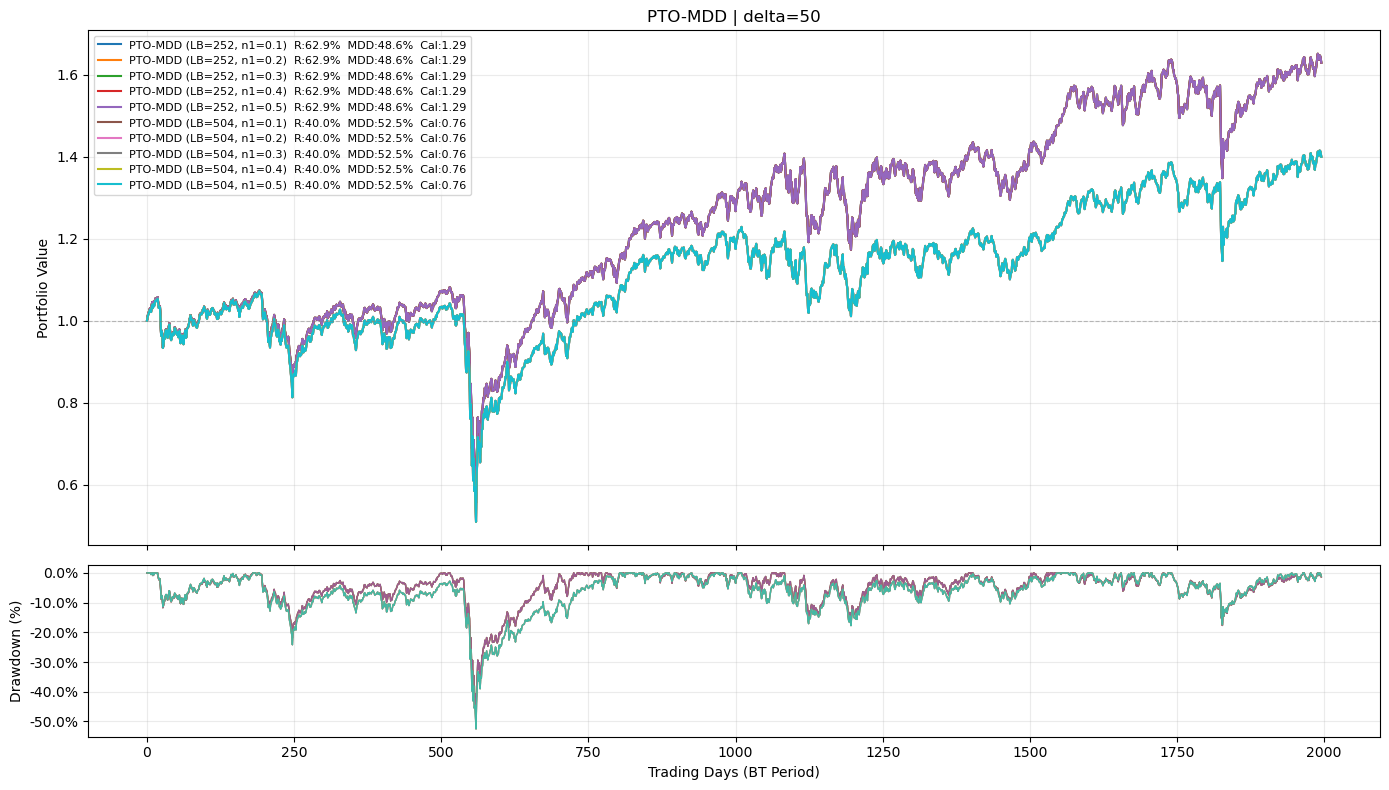


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  PTO-MDD (LB=252, n1=0.1)                6.36%    21.21%    48.63%     0.13
  PTO-MDD (LB=252, n1=0.2)                6.36%    21.21%    48.63%     0.13
  PTO-MDD (LB=252, n1=0.3)                6.36%    21.21%    48.63%     0.13
  PTO-MDD (LB=252, n1=0.4)                6.36%    21.21%    48.63%     0.13
  PTO-MDD (LB=252, n1=0.5)                6.36%    21.21%    48.63%     0.13
  PTO-MDD (LB=504, n1=0.1)                4.34%    22.08%    52.50%     0.08
  PTO-MDD (LB=504, n1=0.2)                4.34%    22.08%    52.50%     0.08
  PTO-MDD (LB=504, n1=0.3)                4.34%    22.08%    52.50%     0.08
  PTO-MDD (LB=504, n1=0.4)                4.34%    22.08%    52.50%     0.08
  PTO-MDD (LB=504, n1=0.5)                4.34%    22.08%    52.50%     0.08


In [101]:
import importlib

import pto_mdd
importlib.reload(pto_mdd)
from pto_mdd import train_pto_mdd, backtest_pto_mdd

for delta_val in DELTA_LIST:
    print(f"\n{'='*50}")
    print(f"  delta={delta_val}")
    print(f"{'='*50}")

    all_results_pto_mdd = []

    for cfg in configs:
        LOOKBACK = cfg["LOOKBACK"]
        n1       = cfg["n1"]

        print(f"\n  ▶ LB={LOOKBACK}, n1={n1} 학습 시작...")

        INPUT_DIM = LOOKBACK * N_STOCKS

        train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                     start=LOOKBACK, end=N_TRAIN)
        val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                     start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
        val_samples   = val_samples[::HORIZON]

        rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                     start=BT_START_IDX, end=BT_START_IDX + N_BT)
        rebal_samples = rebal_samples[::REBAL]

        torch.manual_seed(42)

        model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
        train_pto_mdd(model_pto_mdd, train_samples, val_samples,
                      EPOCHS, BATCH_SIZE, LR, patience=PATIENCE)

        bt_pto_mdd = backtest_pto_mdd(
            model_pto_mdd, rebal_samples, N, d, C,
            n1=n1, x_min=x_min, x_max=x_max, gamma=gamma,
            delta=delta_val,
            is_mean=is_mean, is_std=is_std,
            stock_names=stock_names, rebal=REBAL,
        )
        all_results_pto_mdd.append((bt_pto_mdd, f"PTO-MDD (LB={LOOKBACK}, n1={n1})"))

    plot_multi_pnl(all_results_pto_mdd, title=f"PTO-MDD | delta={delta_val}")

    plot_mdd_distribution(
        all_results_pto_mdd,
        title_prefix=f"PTO-MDD | delta={delta_val}"
    )


############################################################
  PTO-MVO  |  delta = 20
############################################################

  Config: LOOKBACK=252

── PTO-MVO Training (MSE + Val Early Stopping) ──
  Epoch   1/500  train=0.003940  val=0.001137  *
  Epoch   5/500  train=0.000282  val=0.000170  *
  Epoch  10/500  train=0.000222  val=0.000100  *
  Epoch  15/500  train=0.000222  val=0.000088  *
  Epoch  20/500  train=0.000223  val=0.000086  *
  Epoch  25/500  train=0.000224  val=0.000085  *
  Epoch  30/500  train=0.000226  val=0.000085  (2/50)
  Epoch  35/500  train=0.000224  val=0.000085  (3/50)
  Epoch  40/500  train=0.000224  val=0.000085  (8/50)
  Epoch  45/500  train=0.000223  val=0.000085  (4/50)
  Epoch  50/500  train=0.000223  val=0.000085  (9/50)
  Epoch  55/500  train=0.000224  val=0.000085  (14/50)
  Epoch  60/500  train=0.000223  val=0.000085  (19/50)
  Epoch  65/500  train=0.000223  val=0.000085  (24/50)
  Epoch  70/500  train=0.000224  val=0.000085  (

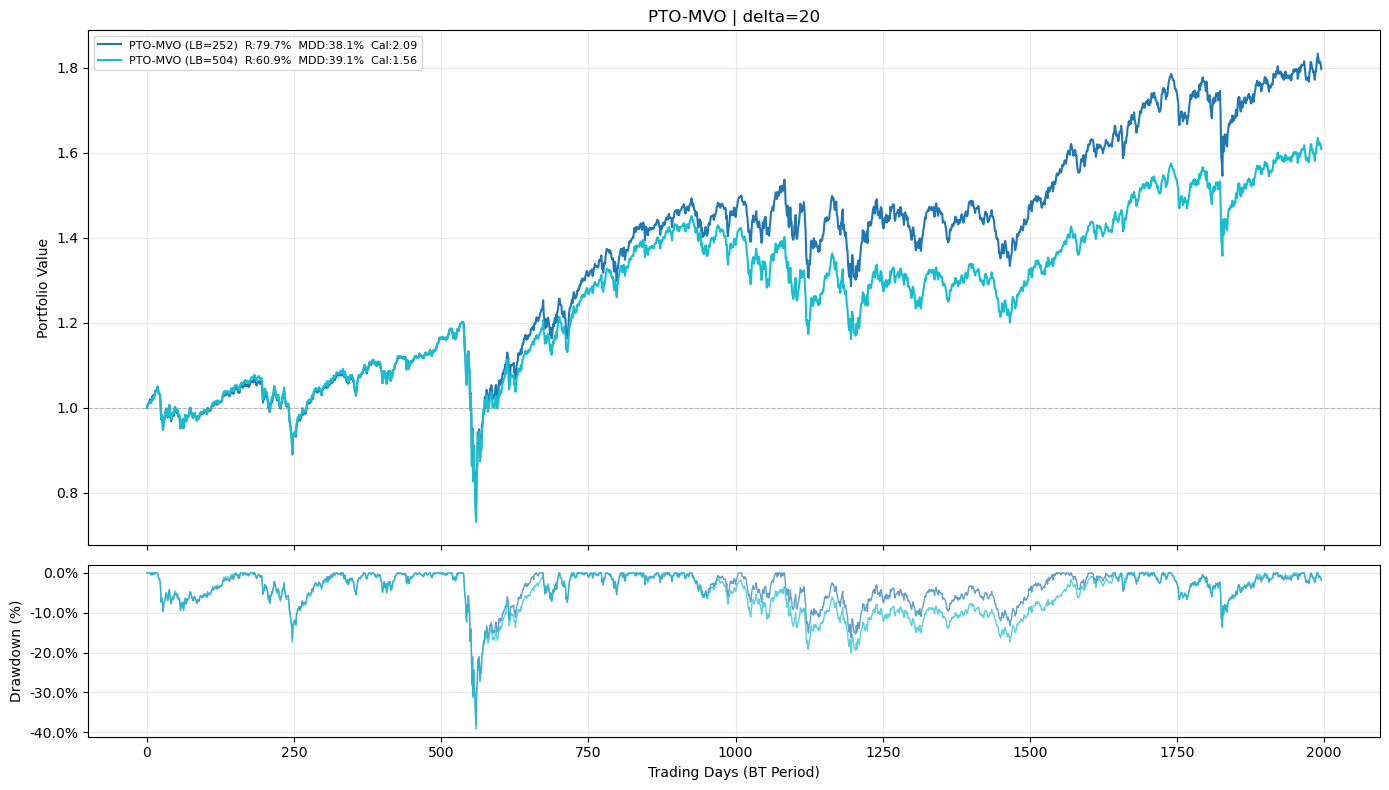


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  PTO-MVO (LB=252)                        7.69%    17.89%    38.09%     0.20
  PTO-MVO (LB=504)                        6.19%    18.28%    39.15%     0.16
───────────────────────────────────────────────────────────────────────────

############################################################
  PTO-MVO  |  delta = 50
############################################################

  Config: LOOKBACK=252

── PTO-MVO Training (MSE + Val Early Stopping) ──
  Epoch   1/500  train=0.003940  val=0.001137  *
  Epoch   5/500  train=0.000282  val=0.000170  *
  Epoch  10/500  train=0.000222  val=0.000100  *
  Epoch  15/500  train=0.000222  val=0.000088  *
  Epoch  20/500  train=0.000223  val=0.000086  *
  Epoch  25/500  train=0.000224  val=0.000085  *
  Epoch  30/500  train=

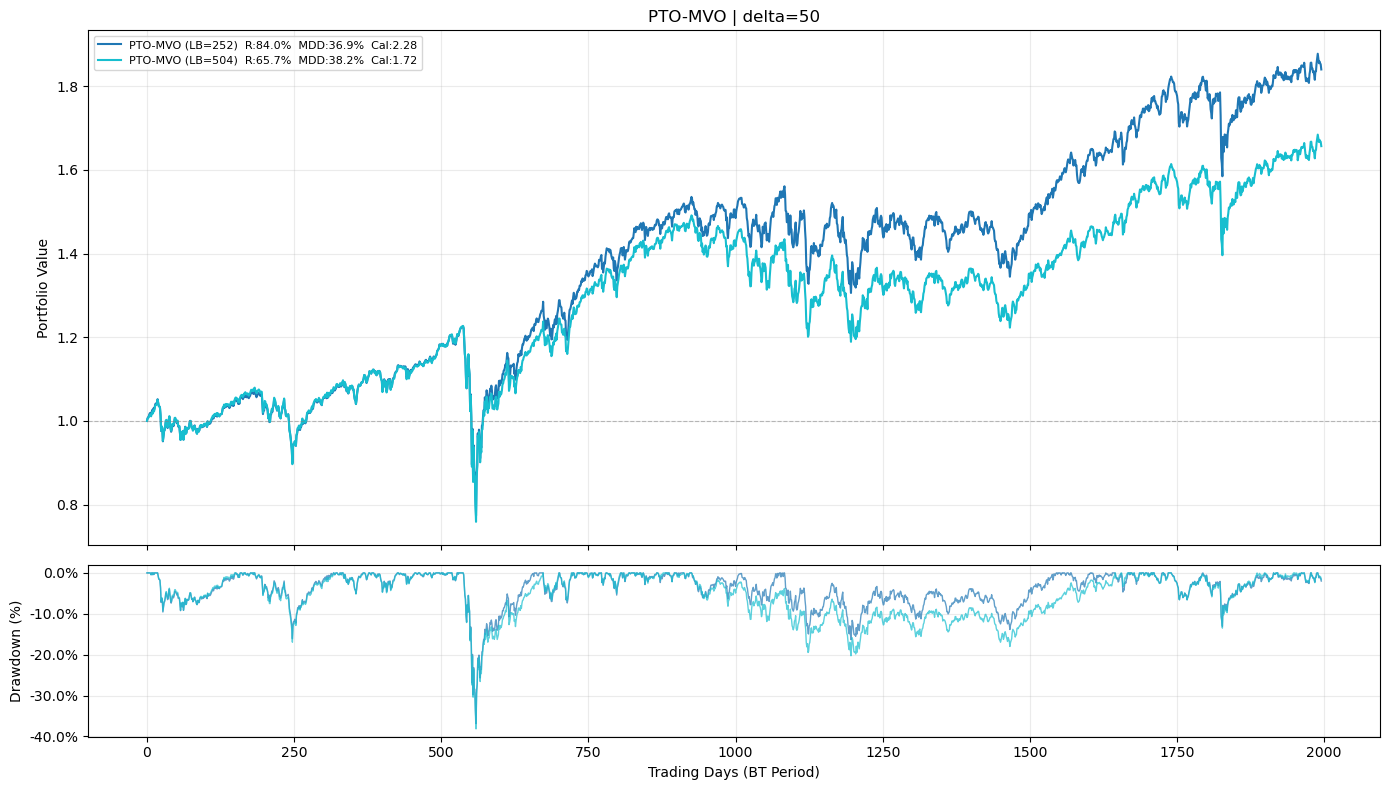


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  PTO-MVO (LB=252)                        8.01%    17.66%    36.87%     0.22
  PTO-MVO (LB=504)                        6.59%    18.10%    38.16%     0.17
───────────────────────────────────────────────────────────────────────────


In [102]:
import importlib

import pto_mvo
importlib.reload(pto_mvo)
from pto_mvo import train_pto_mvo, backtest_pto_mvo

for delta_val in DELTA_LIST:
    print(f"\n{'='*50}")
    print(f"  delta={delta_val}")
    print(f"{'='*50}")

    all_results_mvo = []

    for lookback in LOOKBACK_LIST:
        print(f"\n  ▶ LB={lookback} 학습 시작...")

        INPUT_DIM = lookback * N_STOCKS

        train_samples = make_windows(full_np, lookback, HORIZON,
                                     start=lookback, end=N_TRAIN)
        val_samples   = make_windows(full_np, lookback, HORIZON,
                                     start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
        val_samples   = val_samples[::HORIZON]

        rebal_samples = make_windows(full_np, lookback, HORIZON,
                                     start=BT_START_IDX, end=BT_START_IDX + N_BT)
        rebal_samples = rebal_samples[::REBAL]

        torch.manual_seed(42)

        model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
        train_pto_mvo(model_pto_mvo, train_samples, val_samples,
                      EPOCHS, BATCH_SIZE, LR, patience=PATIENCE)

        bt_pto_mvo = backtest_pto_mvo(
            model_pto_mvo, rebal_samples, N, d, C,
            delta=delta_val,
            x_min=x_min, x_max=x_max, gamma=gamma,
            is_mean=is_mean, is_std=is_std,
            stock_names=stock_names,
            rebal=REBAL,
        )
        all_results_mvo.append((bt_pto_mvo, f"PTO-MVO (LB={lookback})"))

    plot_multi_pnl(all_results_mvo, title=f"PTO-MVO | delta={delta_val}")

    plot_mdd_distribution(
        all_results_mvo,                          # ← 오타 수정
        title_prefix=f"PTO-MVO | delta={delta_val}"
    )